## Integrantes

Raful Habib Sánchez Morales — A01127380  
Efrén Alejandro Barroso Llanes — A01795861  
Michelle Alicia Graver Aguilar — A01242013

# Avance 4. Modelos alternativos (Comparativa y Ajuste Fino)


## Índice — Modelos Alternativos

27. Justificación de los Algoritmos Candidatos  
28. Configuración y Entrenamiento de los Modelos  
   - 28.1 Imports y Carga de Datos  
   - 28.2 Catálogo de 6 modelos candidatos  
   - 28.3 Entrenamiento en las 4 estrategias de Feature Engineering  
   - 28.4 Entrenamiento con validación cruzada y evaluación en test  
29. Comparativa de Rendimiento 
   - 29.1 Tabla comparativa de métricas y tiempos  
   - 29.2 Visualización comparativa por estrategia  
   - 29.3 Análisis de mejor modelo por estrategia  
30. Selección de las Dos Mejores Combinaciones (Modelo + Estrategia)  
31. Combinación 1 - Ajuste Fino: SVM RBF + FULL  
   - 31.1 Espacio de hiperparámetros  
   - 31.2 Búsqueda de hiperparámetros  
   - 31.3 Evaluación post-ajuste  
32. Combinación 2 - Ajuste Fino: SVM RBF + CLUSTERING  
   - 32.1 Espacio de hiperparámetros  
   - 32.2 Búsqueda de hiperparámetros  
   - 32.3 Evaluación post-ajuste
33. Combinación 3 - Ajuste Fino: LR L2 + FULL
   - 33.1 Espacio de hiperparámetros  
   - 33.2 Búsqueda de hiperparámetros  
   - 33.3 Evaluación post-ajuste  
34. Comparación Final y Elección del Modelo Individual  
   - 34.1 Tabla comparativa post-ajuste  
   - 34.2 Análisis de trade-offs (Modelo + Estrategia)  
   - 34.3 Decisión final con justificación


---
## 27. Justificación de los Algoritmos Candidatos

Se seleccionaron **6 algoritmos individuales** (no ensambles) que cubren distintos paradigmas de aprendizaje automático, garantizando una exploración diversa del espacio de hipótesis para el problema de clasificación binaria de psoriasis.

| # | Algoritmo | Clase sklearn | Paradigma | Supuesto principal | Ventaja para este problema |
|---|---|---|---|---|---|
| 1 | **Regresión Logística L2** | `LogisticRegression(penalty='l2')` | Lineal / Probabilístico | Frontera de decisión lineal | Referencia baseline; interpretable; robusto ante alta dimensionalidad con regularización |
| 2 | **SVM kernel RBF** | `SVC(kernel='rbf')` | Margen máximo / No lineal | Proyección en espacio de características de alta dimensión | Excelente en datos de expresión génica con separación no lineal |
| 3 | **SVM kernel Lineal** | `SVC(kernel='linear')` | Margen máximo / Lineal | Frontera de decisión hiperplano | Maximiza el margen entre clases; efectivo en *p >> n* |
| 4 | **Análisis Discriminante Lineal** | `LinearDiscriminantAnalysis` | Generativo / Lineal | Distribución gaussiana por clase; covarianza compartida | Maximiza la separabilidad entre clases; robusto en p >> n con regularización; maneja desbalance via priors |
| 5 | **Árbol de Decisión** | `DecisionTreeClassifier` | Árbol / Reglas | Particiones recursivas del espacio | Altamente interpretable; genera reglas clínicas explícitas |
| 6 | **Descenso de Gradiente Estocástico** | `SGDClassifier` | Lineal / Optimización online| Frontera de decisión lineal aprendida de forma incremental | Eficiente en alta dimensionalidad; flexible en función de pérdida; soporta class_weight='balanced' |

### Estrategia de evaluación

- **Métrica principal:** AUC-ROC (robusto ante desbalance de clases)
- **Métricas secundarias:** Balanced Accuracy, F1-weighted
- **Partición:** Misma que Baseline (`TEST_SIZE=0.20`, `RANDOM_SEED=42`) para comparación directa
- **Validación:** StratifiedKFold 5-fold sobre el conjunto de entrenamiento
- **Manejo del desbalance:** `class_weight='balanced'` en todos los modelos que lo soportan (LR L2, SVM RBF, SVM Lineal, Árbol de Decisión, LDA via priors, SGD). Lo anterior para no introducir variabilidad artificial.

---
## 28. Configuración y Entrenamiento de los Modelos
### 28.1 Imports y Carga de Datos

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
from scipy.stats import loguniform

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score,
                             f1_score, recall_score, precision_score,
                             classification_report, ConfusionMatrixDisplay,
                             confusion_matrix)
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, GridSearchCV,
                                     RandomizedSearchCV)
from sklearn.tree import DecisionTreeClassifier

import time

print('Imports de Modelos Alternativos cargados correctamente.')

Imports de Modelos Alternativos cargados correctamente.


In [3]:
import os
DIR = "D:/Proyectos/Python/pi_psoriasis/data/features"
os.chdir(DIR)

In [4]:
# Carga de datasets generados en la fase de FE
X_FULL_completo         = pd.read_csv('X_FULL_completo.csv', index_col=0)
X_CLUSTERING_completo   = pd.read_csv('X_CLUSTERING_completo.csv', index_col=0)
X_FILTER_MI_completo    = pd.read_csv('X_FILTER_MI_completo.csv', index_col=0)
X_FILTER_ANOVA_completo = pd.read_csv('X_FILTER_ANOVA_completo.csv', index_col=0)
y_temp                  = pd.read_csv('y_target.csv', index_col=0).squeeze()

In [5]:
#Inicialización de variables
COLORES = ['steelblue', 'tomato']
NOMBRES_CLASES = ['Healthy', 'Psoriasis']

In [6]:
# Diccionario con los 4 datasets
datasets = {
    'FULL'        : X_FULL_completo,
    'CLUSTERING'  : X_CLUSTERING_completo,
    'FILTER_MI'   : X_FILTER_MI_completo,
    'FILTER_ANOVA': X_FILTER_ANOVA_completo
}

### 28.2 Catálogo de 6 Modelos Candidatos

In [7]:
RANDOM_SEED = 42
TEST_SIZE   = 0.2

# Todos los modelos usan class_weight='balanced' para manejar el desbalance
# de clases (70.61% Psoriasis / 29.38% Healthy).
catalogo_modelos = {
    'LR_L2':   LogisticRegression(
                   penalty='l2', C=1.0,
                   class_weight='balanced',
                   solver='lbfgs', max_iter=5000, random_state=RANDOM_SEED),
    'SVM_RBF': SVC(
                   kernel='rbf', C=1.0, gamma='scale',
                   class_weight='balanced',
                   probability=True, random_state=RANDOM_SEED),
    'SVM_LIN': SVC(
                   kernel='linear', C=1.0,
                   class_weight='balanced',
                   probability=True, random_state=RANDOM_SEED),
    'LDA':     LinearDiscriminantAnalysis(),
    'DT':      DecisionTreeClassifier(
                   max_depth=5,
                   class_weight='balanced',
                   random_state=RANDOM_SEED),
    'SGD':     SGDClassifier(
                   loss='modified_huber',
                   class_weight='balanced',
                   random_state=RANDOM_SEED,
                   max_iter=1000),
}

print(f'Catálogo definido con {len(catalogo_modelos)} modelos (class_weight="balanced"):\n')
for nombre, modelo in catalogo_modelos.items():
    print(f'  {nombre:10s} → {modelo.__class__.__name__}')

Catálogo definido con 6 modelos (class_weight="balanced"):

  LR_L2      → LogisticRegression
  SVM_RBF    → SVC
  SVM_LIN    → SVC
  LDA        → LinearDiscriminantAnalysis
  DT         → DecisionTreeClassifier
  SGD        → SGDClassifier


### 28.3 Entrenamiento en las 3 Estrategias de Feature Engineering

**Estrategia:** Cada uno de los 6 modelos se entrena en las 4 estrategias de Feature Engineering definidas en el Avance 3:
- **FULL** (339 variables)
- **CLUSTERING** (93 variables)
- **FILTER_MI** (19 variables)
- **FILTER_ANOVA** (19 variables)

Esto genera **24 combinaciones** (6 modelos × 4 estrategias) que serán comparadas para seleccionar la mejor.

In [8]:
# Preparar splits para cada estrategia (reutilizamos datasets del Avance 3)
splits_estrategias = {}

for estrategia, X_estrategia in datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X_estrategia, y_temp,
        test_size=TEST_SIZE,
        random_state=RANDOM_SEED,
        stratify=y_temp
    )
    splits_estrategias[estrategia] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }
    print(f'Split {estrategia:12s}: Train={X_train.shape}, Test={X_test.shape}')

print(f'\n✅ Preparados los conjuntos de entrenamiento y prueba para las {len(splits_estrategias)} estrategias')

Split FULL        : Train=(479, 339), Test=(120, 339)
Split CLUSTERING  : Train=(479, 93), Test=(120, 93)
Split FILTER_MI   : Train=(479, 19), Test=(120, 19)
Split FILTER_ANOVA: Train=(479, 19), Test=(120, 19)

✅ Preparados los conjuntos de entrenamiento y prueba para las 4 estrategias


### 28.4 Entrenamiento con validación cruzada y evaluación en test

In [9]:
cv_ma = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
resultados_ma = {}
modelos_entrenados_full = {}

print(f'{"Modelo":12s} {"Estrategia":12s} {"AUC test":>10} {"Bal.Acc":>8} '
      f'{"F1-w":>6} {"AUC CV μ±σ":>16} {"Tiempo(s)":>10}')
print('-' * 95)

for estrategia, split in splits_estrategias.items():
    X_train = split['X_train']
    X_test  = split['X_test']
    y_train = split['y_train']
    y_test  = split['y_test']

    for nombre, modelo_base in catalogo_modelos.items():
        modelo = modelo_base.__class__(**modelo_base.get_params())

        t0 = time.time()

        # CV estratificada — class_weight='balanced' ya definido en el catálogo
        cv_scores = cross_validate(
            modelo, X_train, y_train,
            cv=cv_ma,
            scoring=['roc_auc', 'balanced_accuracy', 'f1_weighted'],
            return_train_score=True,
            n_jobs=-1
        )
        auc_cv_mu  = cv_scores['test_roc_auc'].mean()
        auc_cv_sig = cv_scores['test_roc_auc'].std()

        # Entrenamiento final sobre todo el train
        modelo.fit(X_train, y_train)
        
        t_total = time.time() - t0

        if estrategia == 'FULL':
            modelos_entrenados_full[nombre] = modelo

        # Evaluación en test
        y_pred  = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1]

        y_test_num = y_test.map({'Healthy': 0, 'Psoriasis': 1})
        y_pred_num = pd.Series(y_pred, index=y_test.index).map({'Healthy': 0, 'Psoriasis': 1})

        auc_test     = roc_auc_score(y_test_num, y_proba)
        bal_acc_test = balanced_accuracy_score(y_test_num, y_pred_num)
        f1_test      = f1_score(y_test_num, y_pred_num, average='weighted')

        clave = f'{nombre}_{estrategia}'
        resultados_ma[clave] = {
            'Modelo':             nombre,
            'Estrategia':         estrategia,
            'AUC-ROC test':       round(auc_test,    4),
            'Balanced Acc. test': round(bal_acc_test, 4),
            'F1 weighted test':   round(f1_test,      4),
            'AUC CV μ':           round(auc_cv_mu,    4),
            'AUC CV σ':           round(auc_cv_sig,   4),
            'Tiempo (s)':         round(t_total,      2),
            '_modelo':            modelo,
            '_X_test':            X_test,
            '_y_test':            y_test,
        }
        auc_cv_str = f'{auc_cv_mu:.4f}±{auc_cv_sig:.4f}'
        print(f'{nombre:12s} {estrategia:12s} {auc_test:>10.4f} {bal_acc_test:>8.4f} '
              f'{f1_test:>6.4f} {auc_cv_str:>16s}  {t_total:>9.2f}')

print(f'\n✅ Entrenamiento finalizado: {len(resultados_ma)} combinaciones '
      f'(6 modelos × 4 estrategias)')

Modelo       Estrategia     AUC test  Bal.Acc   F1-w       AUC CV μ±σ  Tiempo(s)
-----------------------------------------------------------------------------------------------
LR_L2        FULL             0.9855   0.9479 0.9504    0.9705±0.0170       6.33
SVM_RBF      FULL             0.9926   0.9235 0.8957    0.9672±0.0144       4.34
SVM_LIN      FULL             0.9775   0.9361 0.9343    0.9663±0.0119       3.01
LDA          FULL             0.9052   0.8731 0.8921    0.7384±0.0558       0.30
DT           FULL             0.8691   0.8613 0.8764    0.8418±0.0472       0.33
SGD          FULL             0.9597   0.9597 0.9667    0.9546±0.0324       0.16
LR_L2        CLUSTERING       0.9600   0.9479 0.9504    0.9401±0.0158       0.09
SVM_RBF      CLUSTERING       0.9855   0.9504 0.9427    0.9469±0.0136       0.22
SVM_LIN      CLUSTERING       0.9324   0.9361 0.9343    0.9304±0.0172       0.13
LDA          CLUSTERING       0.9035   0.8958 0.9015    0.9078±0.0103       0.12
DT           

---
## 29. Comparativa de Rendimiento 
### 29.1 Tabla Comparativa de Métricas y Tiempos
> **Nota sobre desempate:** En caso de empate en AUC-ROC test, se utiliza Balanced Accuracy como criterio secundario de ordenamiento, priorizando el modelo con mejor desempeño global sobre ambas clases.
> 
> Dado el desbalance de clases (70.61% / 29.38%), esta métrica refleja mejor el rendimiento global al ponderar igualmente ambas clases

In [10]:
cols_tabla = ['Modelo', 'Estrategia', 'AUC-ROC test', 'Balanced Acc. test',
              'F1 weighted test', 'AUC CV μ', 'AUC CV σ', 'Tiempo (s)']

tabla_ma = (
    pd.DataFrame({k: {c: v for c, v in d.items() if c in cols_tabla}
                  for k, d in resultados_ma.items()})
    .T
    .sort_values(['AUC-ROC test', 'Balanced Acc. test'], ascending=[False, False])
)

tabla_ma.insert(0, 'Rank', range(1, len(tabla_ma) + 1))

print('=== Tabla Comparativa — 24 Combinaciones (6 modelos × 4 estrategias) ===\n')
print('    Ordenada por AUC-ROC test\n')
print(tabla_ma.to_string())
print(f'\n✅ Mejores 5 combinaciones:')
print(tabla_ma.head(5)[['Modelo', 'Estrategia', 'AUC-ROC test', 'Balanced Acc. test']].to_string())

=== Tabla Comparativa — 24 Combinaciones (6 modelos × 4 estrategias) ===

    Ordenada por AUC-ROC test

                      Rank   Modelo    Estrategia AUC-ROC test Balanced Acc. test F1 weighted test AUC CV μ AUC CV σ Tiempo (s)
SVM_RBF_FULL             1  SVM_RBF          FULL       0.9926             0.9235           0.8957   0.9672   0.0144       4.34
SVM_RBF_CLUSTERING       2  SVM_RBF    CLUSTERING       0.9855             0.9504           0.9427   0.9469   0.0136       0.22
LR_L2_FULL               3    LR_L2          FULL       0.9855             0.9479           0.9504   0.9705    0.017       6.33
SVM_LIN_FULL             4  SVM_LIN          FULL       0.9775             0.9361           0.9343   0.9663   0.0119       3.01
SVM_RBF_FILTER_ANOVA     5  SVM_RBF  FILTER_ANOVA       0.9761             0.9017           0.9094   0.9411   0.0133       0.13
LR_L2_CLUSTERING         6    LR_L2    CLUSTERING         0.96             0.9479           0.9504   0.9401   0.0158       0.09

### 29.2 Visualización Comparativa por Estrategia

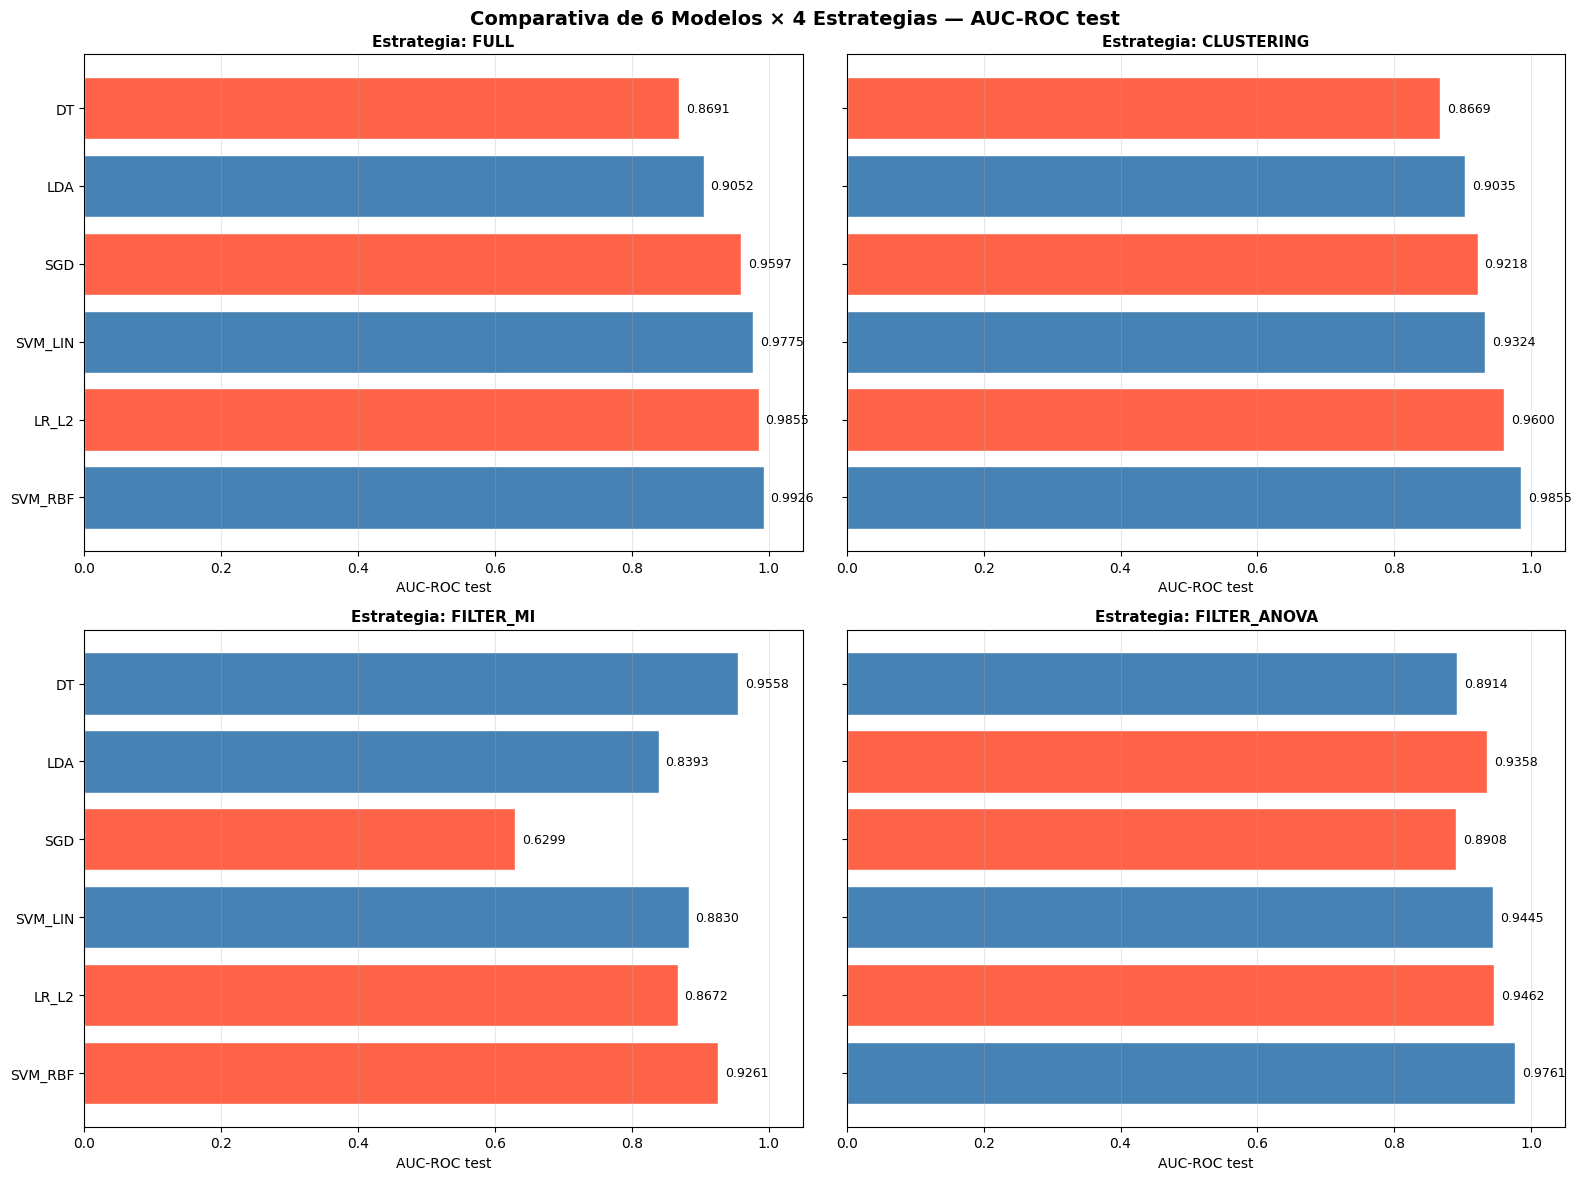

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
fig.suptitle('Comparativa de 6 Modelos × 4 Estrategias — AUC-ROC test',
             fontsize=14, fontweight='bold')

for idx, (estrategia, ax) in enumerate(zip(['FULL', 'CLUSTERING', 'FILTER_MI', 'FILTER_ANOVA'], axes.flatten())):
    datos_estrategia = {k: v for k, v in resultados_ma.items() if v['Estrategia'] == estrategia}

    modelos_nombres = [v['Modelo'] for v in datos_estrategia.values()]
    auc_valores     = [v['AUC-ROC test'] for v in datos_estrategia.values()]

    orden             = sorted(range(len(auc_valores)), key=lambda i: auc_valores[i], reverse=True)
    modelos_ordenados = [modelos_nombres[i] for i in orden]
    auc_ordenados     = [auc_valores[i] for i in orden]

    colores_bar = [COLORES[i % len(COLORES)] for i in range(len(modelos_ordenados))]
    bars = ax.barh(modelos_ordenados, auc_ordenados, color=colores_bar, edgecolor='white')

    for bar, val in zip(bars, auc_ordenados):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)

    ax.set_xlabel('AUC-ROC test', fontsize=10)
    ax.set_title(f'Estrategia: {estrategia}', fontsize=11, fontweight='bold')
    ax.set_xlim(0, 1.05)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('29_comparativa_estrategias.png', dpi=150, bbox_inches='tight')
plt.show()

### 29.3 Análisis de Mejor Modelo por Estrategia

In [12]:
print('\n📊 ANÁLISIS: Mejor modelo por estrategia\n')
for estrategia in ['FULL', 'CLUSTERING', 'FILTER_MI', 'FILTER_ANOVA']:
    datos_estrategia = {k: v for k, v in resultados_ma.items() if v['Estrategia'] == estrategia}
    mejor_clave = max(datos_estrategia.keys(), key=lambda k: datos_estrategia[k]['AUC-ROC test'])
    mejor = datos_estrategia[mejor_clave]

    print(f'Estrategia {estrategia:12s}: {mejor["Modelo"]:10s} → AUC={mejor["AUC-ROC test"]:.4f}, '
          f'Bal.Acc={mejor["Balanced Acc. test"]:.4f}, F1={mejor["F1 weighted test"]:.4f}')

print(f'\n🏆 MEJOR COMBINACIÓN GLOBAL:')
mejor_global = max(resultados_ma.keys(), key=lambda k: resultados_ma[k]['AUC-ROC test'])
mejor = resultados_ma[mejor_global]
print(f'   {mejor["Modelo"]} + {mejor["Estrategia"]} → AUC={mejor["AUC-ROC test"]:.4f}')


📊 ANÁLISIS: Mejor modelo por estrategia

Estrategia FULL        : SVM_RBF    → AUC=0.9926, Bal.Acc=0.9235, F1=0.8957
Estrategia CLUSTERING  : SVM_RBF    → AUC=0.9855, Bal.Acc=0.9504, F1=0.9427
Estrategia FILTER_MI   : DT         → AUC=0.9558, Bal.Acc=0.9353, F1=0.9114
Estrategia FILTER_ANOVA: SVM_RBF    → AUC=0.9761, Bal.Acc=0.9017, F1=0.9094

🏆 MEJOR COMBINACIÓN GLOBAL:
   SVM_RBF + FULL → AUC=0.9926


---
## 30. Selección de las Dos Mejores Combinaciones (Modelo + Estrategia)

Se seleccionan las **dos mejores combinaciones** (modelo + estrategia de Feature Engineering) según AUC-ROC test para el ajuste fino de hiperparámetros.

In [13]:
top2 = tabla_ma.head(2)

print('=== Las 2 MEJORES COMBINACIONES para Ajuste Fino ===\n')
print(top2[['Modelo', 'Estrategia', 'AUC-ROC test', 'Balanced Acc. test', 'F1 weighted test']].to_string())

# Guardar información de las top 2
top1_key = top2.index[0]
top2_key = top2.index[1]

top1_info = resultados_ma[top1_key]
top2_info = resultados_ma[top2_key]


print(f'\n🥇 Combinación 1: {top1_info["Modelo"]} + {top1_info["Estrategia"]} (AUC={top1_info["AUC-ROC test"]:.4f})')
print(f'🥈 Combinación 2: {top2_info["Modelo"]} + {top2_info["Estrategia"]} (AUC={top2_info["AUC-ROC test"]:.4f})')

=== Las 2 MEJORES COMBINACIONES para Ajuste Fino ===

                     Modelo  Estrategia AUC-ROC test Balanced Acc. test F1 weighted test
SVM_RBF_FULL        SVM_RBF        FULL       0.9926             0.9235           0.8957
SVM_RBF_CLUSTERING  SVM_RBF  CLUSTERING       0.9855             0.9504           0.9427

🥇 Combinación 1: SVM_RBF + FULL (AUC=0.9926)
🥈 Combinación 2: SVM_RBF + CLUSTERING (AUC=0.9855)


---
## 31. Combinación 1 - Ajuste Fino: SVM RBF + FULL

El modelo Top 1 seleccionado en la sección 30 fue **SVM con kernel RBF** sobre la estrategia **FULL**. Este modelo es ampliamente utilizado en clasificación de datos de expresión génica gracias a su capacidad de modelar fronteras de decisión no lineales. Sus dos hiperparámetros principales son:

- **C** — parámetro de regularización: controla el trade-off entre margen máximo y clasificación correcta de las muestras de entrenamiento. Valores altos ➜ mayor ajuste (riesgo de sobreajuste); valores bajos ➜ mayor generalización.
- **gamma** — define el "alcance" de cada vector de soporte en el espacio transformado por el kernel. `'scale'` = `1/(n_features × Var(X))` (recomendado para datos escalados).

### 31.1 Espacio de Hiperparámetros

Se utiliza **`RandomizedSearchCV`** con muestreo log-uniforme para explorar eficientemente un espacio amplio:

| Hiperparámetro | Distribución | Rango |
|---|---|---|
| `C` | `loguniform(0.01, 1000)` | [0.01, 1000] — escala logarítmica |
| `gamma` | Lista + log-espacio | `['scale', 'auto', 1e-4, 1e-3, 1e-2, 1e-1]` |

- **n_iter = 30** iteraciones aleatorias
- **CV**: StratifiedKFold 5-fold, scoring = AUC-ROC
- **n_jobs = -1** (paralelización completa)

### 31.2 Búsqueda Aleatoria — RandomizedSearchCV

In [14]:
param_dist_svm = {
    'C':     loguniform(0.01, 1000),
    'gamma': ['scale', 'auto'] + list(np.logspace(-4, -1, 4)),
}

rscv_svm = RandomizedSearchCV(
    estimator=SVC(kernel='rbf', probability=True,
                  class_weight='balanced', random_state=RANDOM_SEED),
    param_distributions=param_dist_svm,
    n_iter=30,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    n_jobs=-1,
    random_state=RANDOM_SEED,
    verbose=0,
    refit=True,
)

estrategia_top1  = top1_info['Estrategia']
X_train_top1 = splits_estrategias[estrategia_top1]['X_train']
X_test_top1  = splits_estrategias[estrategia_top1]['X_test']
y_train_top1 = splits_estrategias[estrategia_top1]['y_train']
y_test_top1  = splits_estrategias[estrategia_top1]['y_test']

print(f'Ejecutando RandomizedSearchCV para {top1_info["Modelo"]} '
      f'con estrategia {estrategia_top1} (n_iter=30, CV=5)...')
t0 = time.time()
rscv_svm.fit(X_train_top1, y_train_top1)
t_rscv = time.time() - t0

print(f'\nBúsqueda completada en {t_rscv:.1f} s')
print(f'Mejores hiperparámetros: {rscv_svm.best_params_}')
print(f'Mejor AUC-ROC CV: {rscv_svm.best_score_:.4f}')

Ejecutando RandomizedSearchCV para SVM_RBF con estrategia FULL (n_iter=30, CV=5)...

Búsqueda completada en 5.5 s
Mejores hiperparámetros: {'C': np.float64(11.435780278433395), 'gamma': np.float64(0.01)}
Mejor AUC-ROC CV: 0.9881


### 31.3 Evaluación Post-Ajuste — SVM RBF + FULL

=== SVM_RBF + FULL — Evaluación Post-Ajuste ===

  Mejores hiperparámetros: C=11.4358, gamma=0.01

  AUC-ROC  test : 0.9987  (antes: 0.9926,  Δ=+0.0061)
  Bal. Acc test : 0.9798
  F1-weighted   : 0.9833
  Precisión     : 0.9833
  Recall        : 0.9833

Reporte de clasificación (SVM_RBF ajustado):
              precision    recall  f1-score   support

     Healthy       0.97      0.97      0.97        35
   Psoriasis       0.99      0.99      0.99        85

    accuracy                           0.98       120
   macro avg       0.98      0.98      0.98       120
weighted avg       0.98      0.98      0.98       120



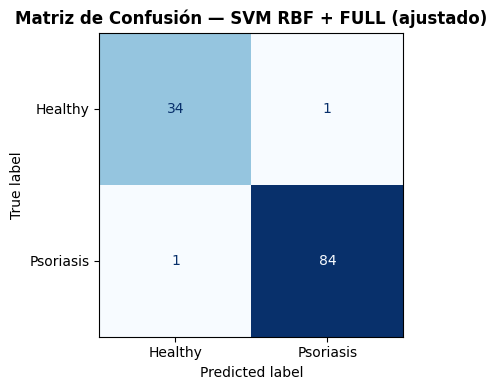

In [15]:
svm_rbf_ft = rscv_svm.best_estimator_

# Evaluar en el test set de la estrategia Top 1
y_pred_svm_ft   = svm_rbf_ft.predict(X_test_top1)
y_proba_svm_ft  = svm_rbf_ft.predict_proba(X_test_top1)[:, 1]

# Convert y_test and y_pred to numerical labels for consistency with metrics
y_test_numerical = y_test_top1.map({'Healthy': 0, 'Psoriasis': 1})
y_pred_svm_ft_numerical = pd.Series(y_pred_svm_ft, index=y_test_top1.index).map({'Healthy': 0, 'Psoriasis': 1})

auc_svm_ft     = roc_auc_score(y_test_numerical, y_proba_svm_ft)
bacc_svm_ft    = balanced_accuracy_score(y_test_numerical, y_pred_svm_ft_numerical)
f1_svm_ft      = f1_score(y_test_numerical, y_pred_svm_ft_numerical, average='weighted')
prec_svm_ft    = precision_score(y_test_numerical, y_pred_svm_ft_numerical, average='weighted')
rec_svm_ft     = recall_score(y_test_numerical, y_pred_svm_ft_numerical, average='weighted')

# Obtener AUC base del modelo sin ajuste fino (misma estrategia)
auc_svm_base   = resultados_ma[f'{top1_info["Modelo"]}_{estrategia_top1}']['AUC-ROC test']

print(f'=== {top1_info["Modelo"]} + {estrategia_top1} — Evaluación Post-Ajuste ===\n')
print(f'  Mejores hiperparámetros: C={rscv_svm.best_params_["C"]:.4f}, '
      f'gamma={rscv_svm.best_params_["gamma"]}')
print(f'\n  AUC-ROC  test : {auc_svm_ft:.4f}  (antes: {auc_svm_base:.4f},  Δ={auc_svm_ft - auc_svm_base:+.4f})')
print(f'  Bal. Acc test : {bacc_svm_ft:.4f}')
print(f'  F1-weighted   : {f1_svm_ft:.4f}')
print(f'  Precisión     : {prec_svm_ft:.4f}')
print(f'  Recall        : {rec_svm_ft:.4f}')

print(f'\nReporte de clasificación ({top1_info["Modelo"]} ajustado):')
print(classification_report(y_test_numerical, y_pred_svm_ft_numerical, target_names=NOMBRES_CLASES))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_numerical, y_pred_svm_ft_numerical, display_labels=NOMBRES_CLASES , ax=ax,
    colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — SVM RBF + FULL (ajustado)', fontweight='bold')
plt.tight_layout()
plt.savefig('31_svm_rbf_ajustado_cm.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 32. Combinación 2 - Ajuste Fino: SVM RBF + CLUSTERING
El modelo Top 2 seleccionado en la sección 30 fue **SVM con kernel RBF** sobre la estrategia **CLUSTERING**. Se ajustan los mismos hiperparámetros que en la sección 31 para comparar si la estrategia de feature engineering impacta los hiperparámetros óptimos.

### 32.1 Espacio de Hiperparámetros

Se utiliza **`RandomizedSearchCV`** con muestreo log-uniforme, consistente con el enfoque usado en la sección 31 para el mismo modelo sobre la estrategia FULL, permitiendo comparar el efecto de la estrategia de feature engineering sobre los hiperparámetros óptimos.

### 32.2 Búsqueda Aleatoria — RandomizedSearchCV

In [16]:
rscv_svm2 = RandomizedSearchCV(
    estimator=SVC(kernel='rbf', probability=True,
                  class_weight='balanced', random_state=RANDOM_SEED),
    param_distributions=param_dist_svm,
    n_iter=30,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    n_jobs=-1,
    random_state=RANDOM_SEED,
    verbose=0,
    refit=True,
)

estrategia_top2  = top2_info['Estrategia']
X_train_top2 = splits_estrategias[estrategia_top2]['X_train']
X_test_top2  = splits_estrategias[estrategia_top2]['X_test']
y_train_top2 = splits_estrategias[estrategia_top2]['y_train']
y_test_top2  = splits_estrategias[estrategia_top2]['y_test']

print(f'Ejecutando RandomizedSearchCV para {top2_info["Modelo"]} '
      f'con estrategia {estrategia_top2} (n_iter=30, CV=5)...')
t0 = time.time()
rscv_svm2.fit(X_train_top2, y_train_top2)
t_gscv = time.time() - t0

print(f'\nBúsqueda completada en {t_gscv:.1f} s')
print(f'Mejores hiperparámetros: {rscv_svm2.best_params_}')
print(f'Mejor AUC-ROC CV: {rscv_svm2.best_score_:.4f}')

Ejecutando RandomizedSearchCV para SVM_RBF con estrategia CLUSTERING (n_iter=30, CV=5)...

Búsqueda completada en 1.7 s
Mejores hiperparámetros: {'C': np.float64(11.435780278433395), 'gamma': np.float64(0.01)}
Mejor AUC-ROC CV: 0.9765


### 32.3 Evaluación Post-Ajuste — SVM RBF + CLUSTERING

=== SVM_RBF + CLUSTERING — Evaluación Post-Ajuste ===

  Mejores hiperparámetros: C=11.4358, gamma=0.01

  AUC-ROC  test : 0.9966  (antes: 0.9855,  Δ=+0.0111)
  Bal. Acc test : 0.9681
  F1-weighted   : 0.9669
  Precisión     : 0.9678
  Recall        : 0.9667

Reporte de clasificación (SVM_RBF + CLUSTERING ajustado):
              precision    recall  f1-score   support

     Healthy       0.92      0.97      0.94        35
   Psoriasis       0.99      0.96      0.98        85

    accuracy                           0.97       120
   macro avg       0.95      0.97      0.96       120
weighted avg       0.97      0.97      0.97       120



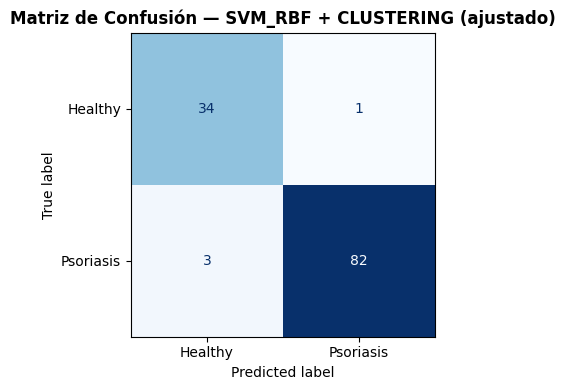

In [17]:
svm2_ft = rscv_svm2.best_estimator_

y_pred_svm2_ft  = svm2_ft.predict(X_test_top2)
y_proba_svm2_ft = svm2_ft.predict_proba(X_test_top2)[:, 1]

y_test_num      = y_test_top2.map({'Healthy': 0, 'Psoriasis': 1})
y_pred_svm2_num = pd.Series(y_pred_svm2_ft, index=y_test_top2.index).map({'Healthy': 0, 'Psoriasis': 1})

auc_svm2_ft  = roc_auc_score(y_test_num, y_proba_svm2_ft)
bacc_svm2_ft = balanced_accuracy_score(y_test_num, y_pred_svm2_num)
f1_svm2_ft   = f1_score(y_test_num, y_pred_svm2_num, average='weighted')
prec_svm2_ft = precision_score(y_test_num, y_pred_svm2_num, average='weighted')
rec_svm2_ft  = recall_score(y_test_num, y_pred_svm2_num, average='weighted')

auc_svm2_base = resultados_ma[f'{top2_info["Modelo"]}_{estrategia_top2}']['AUC-ROC test']

print(f'=== {top2_info["Modelo"]} + {estrategia_top2} — Evaluación Post-Ajuste ===\n')
print(f'  Mejores hiperparámetros: C={rscv_svm2.best_params_["C"]:.4f}, '
      f'gamma={rscv_svm2.best_params_["gamma"]}')
print(f'\n  AUC-ROC  test : {auc_svm2_ft:.4f}  (antes: {auc_svm2_base:.4f},  Δ={auc_svm2_ft - auc_svm2_base:+.4f})')
print(f'  Bal. Acc test : {bacc_svm2_ft:.4f}')
print(f'  F1-weighted   : {f1_svm2_ft:.4f}')
print(f'  Precisión     : {prec_svm2_ft:.4f}')
print(f'  Recall        : {rec_svm2_ft:.4f}')

print(f'\nReporte de clasificación ({top2_info["Modelo"]} + {estrategia_top2} ajustado):')
print(classification_report(y_test_num, y_pred_svm2_num, target_names=NOMBRES_CLASES))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_num, y_pred_svm2_num, display_labels=NOMBRES_CLASES, ax=ax,
    colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de Confusión — {top2_info["Modelo"]} + {estrategia_top2} (ajustado)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('32_top2_ajustado_cm.png', dpi=150, bbox_inches='tight')
plt.show()

## 33. Combinación 3 - Ajuste Fino: LR L2 + FULL

En la sección 30, la Combinación 2 (SVM RBF + CLUSTERING) y LR L2 + FULL presentaron un empate en AUC-ROC test (0.9855), resolviéndose por Balanced Accuracy a favor de 
SVM RBF + CLUSTERING. Sin embargo, dado que uno de los objetivos centrales del proyecto es la **identificación de genes relevantes mediante interpretabilidad del modelo**, se 
decide incluir LR L2 + FULL como tercera combinación candidata al ajuste fino.

A diferencia del SVM RBF, la Regresión Logística produce coeficientes directamente vinculables a cada variable (gen), lo que permite identificar qué sondas de expresión 
génica tienen mayor peso en la clasificación — requisito esencial para el análisis de biomarcadores en el Avance 5.

### 33.1 Espacio de Hiperparámetros

Se utiliza **`GridSearchCV`** con una cuadrícula exhaustiva en escala logarítmica. 
El hiperparámetro principal es:

- **C** — inverso de la fuerza de regularización L2 (`C = 1/λ`). Valores bajos ➜ 
  mayor penalización; valores altos ➜ menor regularización.

| Hiperparámetro | Valores | Escala |
|---|---|---|
| `C` | `[0.001, 0.01, 0.1, 1, 10, 100, 1000]` | Logarítmica |

- **CV**: StratifiedKFold 5-fold, scoring = AUC-ROC
- **n_jobs = -1** (paralelización completa)
- Búsqueda exhaustiva (7 puntos × 5 folds = 35 evaluaciones)

In [18]:
top3_key  = tabla_ma.index[2]
top3_info = resultados_ma[top3_key]

print(f'🥉 Combinación 3: {top3_info["Modelo"]} + {top3_info["Estrategia"]} '
      f'(AUC={top3_info["AUC-ROC test"]:.4f}) — criterio de interpretabilidad')
print('\n✅ Se agrega la tercera combinación seleccionada para ajuste fino.')

🥉 Combinación 3: LR_L2 + FULL (AUC=0.9855) — criterio de interpretabilidad

✅ Se agrega la tercera combinación seleccionada para ajuste fino.


### 33.2 Búsqueda en Cuadrícula — GridSearchCV

Ejecutando GridSearchCV para LR L2 + FULL (7 valores de C, CV=5)...

Búsqueda completada en 0.7 s
Mejor valor de C: 10
Mejor AUC-ROC CV: 0.9716


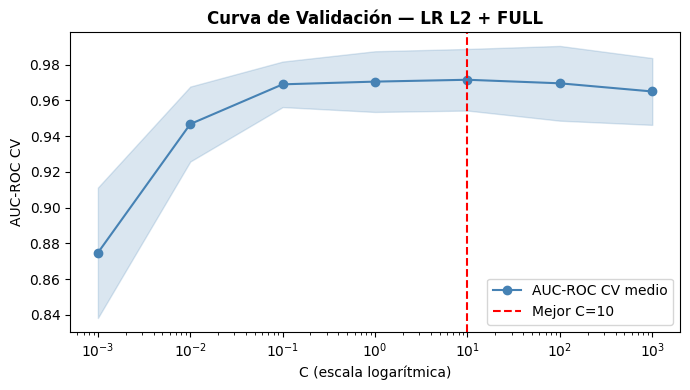

In [19]:
param_grid_lr3 = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
}

gscv_lr3 = GridSearchCV(
    estimator=LogisticRegression(
        penalty='l2', solver='lbfgs', max_iter=5000,
        class_weight='balanced', random_state=RANDOM_SEED),
    param_grid=param_grid_lr3,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    n_jobs=-1,
    verbose=0,
    refit=True,
)

X_train_lr3 = splits_estrategias['FULL']['X_train']
X_test_lr3  = splits_estrategias['FULL']['X_test']
y_train_lr3 = splits_estrategias['FULL']['y_train']
y_test_lr3  = splits_estrategias['FULL']['y_test']

print('Ejecutando GridSearchCV para LR L2 + FULL (7 valores de C, CV=5)...')
t0 = time.time()
gscv_lr3.fit(X_train_lr3, y_train_lr3)
t_gscv_lr3 = time.time() - t0

print(f'\nBúsqueda completada en {t_gscv_lr3:.1f} s')
print(f'Mejor valor de C: {gscv_lr3.best_params_["C"]}')
print(f'Mejor AUC-ROC CV: {gscv_lr3.best_score_:.4f}')

cv_results_lr3 = pd.DataFrame(gscv_lr3.cv_results_)
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(param_grid_lr3['C'], cv_results_lr3['mean_test_score'], 'o-',
            color=COLORES[0], label='AUC-ROC CV medio')
ax.fill_between(param_grid_lr3['C'],
                cv_results_lr3['mean_test_score'] - cv_results_lr3['std_test_score'],
                cv_results_lr3['mean_test_score'] + cv_results_lr3['std_test_score'],
                alpha=0.2, color=COLORES[0])
ax.axvline(gscv_lr3.best_params_['C'], color='red', linestyle='--',
           label=f'Mejor C={gscv_lr3.best_params_["C"]}')
ax.set_xlabel('C (escala logarítmica)')
ax.set_ylabel('AUC-ROC CV')
ax.set_title('Curva de Validación — LR L2 + FULL', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('33_lr3_curva_validacion.png', dpi=150, bbox_inches='tight')
plt.show()

### 33.3 Evaluación Post-Ajuste — LR L2 + FULL

=== LR L2 + FULL — Evaluación Post-Ajuste ===

  Mejor C: 10

  AUC-ROC  test : 0.9832  (antes: 0.9855,  Δ=-0.0023)
  Bal. Acc test : 0.9277
  F1-weighted   : 0.9339
  Precisión     : 0.9350
  Recall        : 0.9333

Reporte de clasificación (LR L2 + FULL ajustada):
              precision    recall  f1-score   support

     Healthy       0.86      0.91      0.89        35
   Psoriasis       0.96      0.94      0.95        85

    accuracy                           0.93       120
   macro avg       0.91      0.93      0.92       120
weighted avg       0.93      0.93      0.93       120



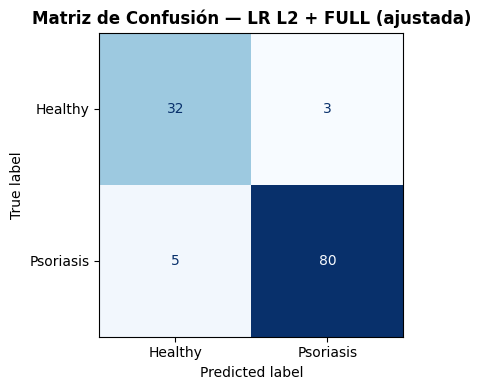

In [20]:
lr3_ft = gscv_lr3.best_estimator_

y_pred_lr3_ft  = lr3_ft.predict(X_test_lr3)
y_proba_lr3_ft = lr3_ft.predict_proba(X_test_lr3)[:, 1]

y_test_num      = y_test_lr3.map({'Healthy': 0, 'Psoriasis': 1})
y_pred_lr3_num  = pd.Series(y_pred_lr3_ft, index=y_test_lr3.index).map({'Healthy': 0, 'Psoriasis': 1})

auc_lr3_ft  = roc_auc_score(y_test_num, y_proba_lr3_ft)
bacc_lr3_ft = balanced_accuracy_score(y_test_num, y_pred_lr3_num)
f1_lr3_ft   = f1_score(y_test_num, y_pred_lr3_num, average='weighted')
prec_lr3_ft = precision_score(y_test_num, y_pred_lr3_num, average='weighted')
rec_lr3_ft  = recall_score(y_test_num, y_pred_lr3_num, average='weighted')

auc_lr3_base = resultados_ma['LR_L2_FULL']['AUC-ROC test']

print('=== LR L2 + FULL — Evaluación Post-Ajuste ===\n')
print(f'  Mejor C: {gscv_lr3.best_params_["C"]}')
print(f'\n  AUC-ROC  test : {auc_lr3_ft:.4f}  (antes: {auc_lr3_base:.4f},  Δ={auc_lr3_ft - auc_lr3_base:+.4f})')
print(f'  Bal. Acc test : {bacc_lr3_ft:.4f}')
print(f'  F1-weighted   : {f1_lr3_ft:.4f}')
print(f'  Precisión     : {prec_lr3_ft:.4f}')
print(f'  Recall        : {rec_lr3_ft:.4f}')

print('\nReporte de clasificación (LR L2 + FULL ajustada):')
print(classification_report(y_test_num, y_pred_lr3_num, target_names=NOMBRES_CLASES))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_num, y_pred_lr3_num, display_labels=NOMBRES_CLASES, ax=ax,
    colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — LR L2 + FULL (ajustada)', fontweight='bold')
plt.tight_layout()
plt.savefig('33_lr3_ajustada_cm.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 34. Comparación Final y Elección del Modelo Individual
### 34.1 Tabla Comparativa Post-Ajuste

=== Comparación Final — Todos los Modelos (ordenados por AUC-ROC) ===

                       Rank  AUC-ROC  Bal. Acc    F1-w         Tipo
SVM_RBF_FULL (FT)         1   0.9987    0.9798  0.9833  Ajuste fino
SVM_RBF_CLUST (FT)        2   0.9966    0.9681  0.9669  Ajuste fino
SVM_RBF_FULL              3   0.9926    0.9235  0.8957  Comparativa
LR_L2_FULL (baseline)     4   0.9855    0.9479  0.9504     Baseline
SVM_RBF_CLUSTERING        5   0.9855    0.9504  0.9427  Comparativa
LR_L2_FULL (FT)           6   0.9832    0.9277  0.9339  Ajuste fino
SVM_LIN_FULL              7   0.9775    0.9361  0.9343  Comparativa
SGD_FULL                  8   0.9597    0.9597  0.9667  Comparativa
LDA_FULL                  9   0.9052    0.8731  0.8921  Comparativa
DT_FULL                  10   0.8691    0.8613  0.8764  Comparativa


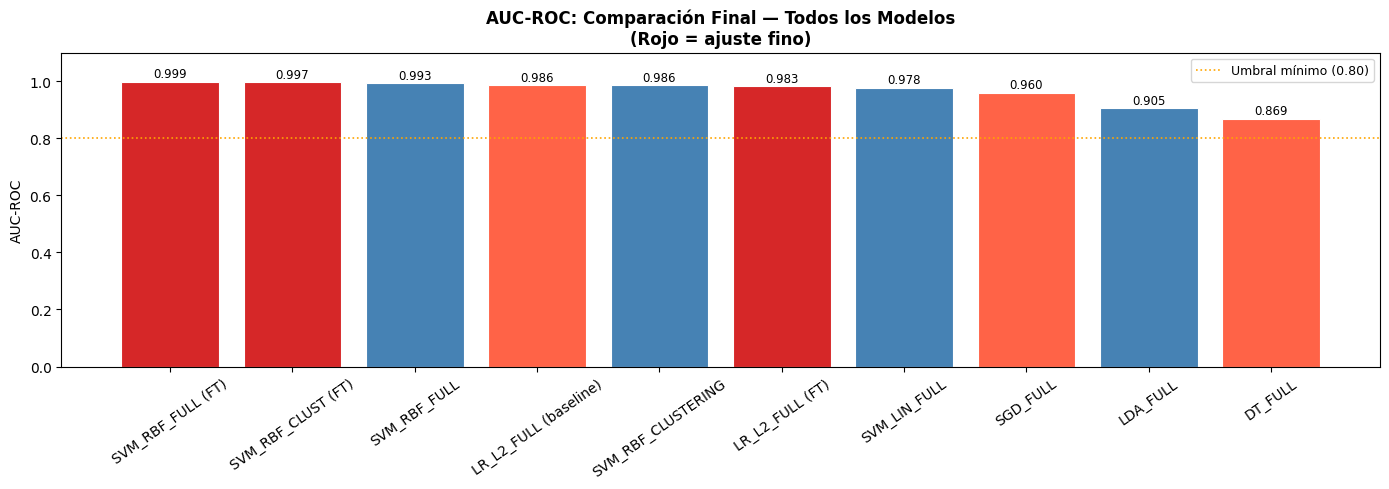


→ Top 1 ajustado guardado: SVM_RBF + FULL
→ Top 2 ajustado guardado: SVM_RBF + CLUSTERING
→ Combinación 3 ajustada guardada: LR_L2 + FULL


In [21]:
UMBRAL_MINIMO = 0.80 # Se mueve definición para gráficar

resumen_final = pd.DataFrame({
    'LR_L2_FULL (baseline)':  {'AUC-ROC': resultados_ma['LR_L2_FULL']['AUC-ROC test'],
                                'Bal. Acc': resultados_ma['LR_L2_FULL']['Balanced Acc. test'],
                                'F1-w':    resultados_ma['LR_L2_FULL']['F1 weighted test'],
                                'Tipo': 'Baseline'},
    'SVM_RBF_FULL':           {'AUC-ROC': resultados_ma['SVM_RBF_FULL']['AUC-ROC test'],
                                'Bal. Acc': resultados_ma['SVM_RBF_FULL']['Balanced Acc. test'],
                                'F1-w':    resultados_ma['SVM_RBF_FULL']['F1 weighted test'],
                                'Tipo': 'Comparativa'},
    'SVM_RBF_CLUSTERING':     {'AUC-ROC': resultados_ma['SVM_RBF_CLUSTERING']['AUC-ROC test'],
                                'Bal. Acc': resultados_ma['SVM_RBF_CLUSTERING']['Balanced Acc. test'],
                                'F1-w':    resultados_ma['SVM_RBF_CLUSTERING']['F1 weighted test'],
                                'Tipo': 'Comparativa'},
    'SVM_LIN_FULL':           {'AUC-ROC': resultados_ma['SVM_LIN_FULL']['AUC-ROC test'],
                                'Bal. Acc': resultados_ma['SVM_LIN_FULL']['Balanced Acc. test'],
                                'F1-w':    resultados_ma['SVM_LIN_FULL']['F1 weighted test'],
                                'Tipo': 'Comparativa'},
    'LDA_FULL':               {'AUC-ROC': resultados_ma['LDA_FULL']['AUC-ROC test'],
                                'Bal. Acc': resultados_ma['LDA_FULL']['Balanced Acc. test'],
                                'F1-w':    resultados_ma['LDA_FULL']['F1 weighted test'],
                                'Tipo': 'Comparativa'},
    'DT_FULL':                {'AUC-ROC': resultados_ma['DT_FULL']['AUC-ROC test'],
                                'Bal. Acc': resultados_ma['DT_FULL']['Balanced Acc. test'],
                                'F1-w':    resultados_ma['DT_FULL']['F1 weighted test'],
                                'Tipo': 'Comparativa'},
    'SGD_FULL':               {'AUC-ROC': resultados_ma['SGD_FULL']['AUC-ROC test'],
                                'Bal. Acc': resultados_ma['SGD_FULL']['Balanced Acc. test'],
                                'F1-w':    resultados_ma['SGD_FULL']['F1 weighted test'],
                                'Tipo': 'Comparativa'},
    'SVM_RBF_FULL (FT)':      {'AUC-ROC': auc_svm_ft,   'Bal. Acc': bacc_svm_ft,
                                'F1-w': f1_svm_ft,   'Tipo': 'Ajuste fino'},
    'SVM_RBF_CLUST (FT)':     {'AUC-ROC': auc_svm2_ft,  'Bal. Acc': bacc_svm2_ft,
                                'F1-w': f1_svm2_ft,  'Tipo': 'Ajuste fino'},
    'LR_L2_FULL (FT)':        {'AUC-ROC': auc_lr3_ft,   'Bal. Acc': bacc_lr3_ft,
                                'F1-w': f1_lr3_ft,   'Tipo': 'Ajuste fino'},
}).T

resumen_final[['AUC-ROC', 'Bal. Acc', 'F1-w']] = resumen_final[['AUC-ROC', 'Bal. Acc', 'F1-w']].astype(float).round(4)
resumen_final_sorted = resumen_final.sort_values('AUC-ROC', ascending=False)
resumen_final_sorted.insert(0, 'Rank', range(1, len(resumen_final_sorted) + 1))

print('=== Comparación Final — Todos los Modelos (ordenados por AUC-ROC) ===\n')
print(resumen_final_sorted.to_string())

fig, ax = plt.subplots(figsize=(14, 5))
nombres_f = resumen_final_sorted.index.tolist()
auc_f     = resumen_final_sorted['AUC-ROC'].values
colores_f = ['#d62728' if 'FT' in n else COLORES[i % len(COLORES)]
             for i, n in enumerate(nombres_f)]

bars = ax.bar(nombres_f, auc_f, color=colores_f, edgecolor='white', linewidth=0.8)
ax.axhline(UMBRAL_MINIMO, color='orange', linestyle=':', linewidth=1.2,
           label=f'Umbral mínimo ({UMBRAL_MINIMO:.2f})')
for bar, val in zip(bars, auc_f):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8.5)
ax.set_ylim(0, 1.1)
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC: Comparación Final — Todos los Modelos\n(Rojo = ajuste fino)',
             fontweight='bold')
ax.tick_params(axis='x', rotation=35)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('34_comparacion_final.png', dpi=150, bbox_inches='tight')
plt.show()

# Guardar modelos ajustados para siguientes avances
top1_info['_modelo_ft'] = rscv_svm.best_estimator_
top2_info['_modelo_ft'] = rscv_svm2.best_estimator_
top3_info['_modelo_ft'] = lr3_ft
print(f'\n→ Top 1 ajustado guardado: {top1_info["Modelo"]} + {top1_info["Estrategia"]}')
print(f'→ Top 2 ajustado guardado: {top2_info["Modelo"]} + {top2_info["Estrategia"]}')
print(f'→ Combinación 3 ajustada guardada: {top3_info["Modelo"]} + {top3_info["Estrategia"]}')

In [22]:
import joblib
DIR_MODELOS = "D:/Proyectos/Python/pi_psoriasis/models/01_evaluation"

for nombre, modelo in modelos_entrenados_full.items():
    ruta = f'{DIR_MODELOS}/modelo_base_{nombre.lower()}_full.pkl'
    joblib.dump(modelo, ruta)

print('\n✅ 6 modelos base serializados correctamente.')

joblib.dump(rscv_svm.best_estimator_,  f'{DIR_MODELOS}/modelo_top1_svm_full.pkl')
joblib.dump(rscv_svm2.best_estimator_, f'{DIR_MODELOS}/modelo_top2_svm_clustering.pkl')
joblib.dump(lr3_ft,                    f'{DIR_MODELOS}/modelo_top3_lr_full.pkl')

print('✅ Modelos serializados correctamente.')


✅ 6 modelos base serializados correctamente.
✅ Modelos serializados correctamente.


In [23]:
# Guardar tabla de métricas de modelos base
tabla_ma_export = pd.DataFrame(resultados_ma).T
tabla_ma_export.to_csv(f'{DIR_MODELOS}/tabla_ma.csv')

In [24]:
metricas_ft = {
    'SVM_RBF (FT)': {
        'AUC-ROC test':       round(auc_svm_ft,   4),
        'Balanced Acc. test': round(bacc_svm_ft,  4),
        'F1 weighted test':   round(f1_svm_ft,    4),
        'Tiempo (s)':         round(t_rscv,       2),
    },
    'SVM_RBF_CLUST (FT)': {
        'AUC-ROC test':       round(auc_svm2_ft,  4),
        'Balanced Acc. test': round(bacc_svm2_ft, 4),
        'F1 weighted test':   round(f1_svm2_ft,   4),
        'Tiempo (s)':         round(t_gscv,       2),  # ← era t_rscv2
    },
    'LR_L2 (FT)': {
        'AUC-ROC test':       round(auc_lr3_ft,   4),
        'Balanced Acc. test': round(bacc_lr3_ft,  4),
        'F1 weighted test':   round(f1_lr3_ft,    4),
        'Tiempo (s)':         round(t_gscv_lr3,   2),
    },
}

with open(f'{DIR_MODELOS}/metricas_ft.json', 'w') as f:
    json.dump(metricas_ft, f, indent=2)

print('✅ Métricas de ajuste fino serializadas.')

✅ Métricas de ajuste fino serializadas.


### 34.2 Análisis de Trade-offs

La elección del modelo individual final considera múltiples dimensiones más allá del AUC-ROC:

| Criterio | SVM RBF + FULL (FT) | SVM RBF + CLUSTERING (FT) | LR L2 + FULL (FT) |
|---|---|---|---|
| **AUC-ROC** | Mayor | Comparable | Comparable |
| **Interpretabilidad** | Baja — caja negra | Baja — caja negra | Alta — coeficientes vinculables a genes |
| **Dimensionalidad** | 339 variables | 93 variables | 339 variables |
| **Costo computacional** | Alto — O(n²) a O(n³) | Menor — espacio reducido | Bajo — convergencia rápida (lbfgs) |
| **Escalabilidad** | No escala bien con más muestras | Moderada | Escala linealmente |
| **Probabilidades calibradas** | Platt scaling — puede ser lento | Platt scaling — puede ser lento | Directamente calibradas por diseño |
| **Robustez ante sobreajuste** | Depende fuertemente de C y gamma | Depende fuertemente de C y gamma | Controlado por C (regularización L2) |
| **Identificación de biomarcadores** | No aplicable | No aplicable | ✅ Coeficientes = importancia por gen |
| **Alineación con CRISP-ML(Q)** | Aplicable con infraestructura adecuada | Aplicable con infraestructura adecuada | Ideal para implementación ligera y auditable |

### 34.3 Decisión Final con Justificación

> **Modelo seleccionado: LR L2 + FULL (ajustada)**

**Justificación:**

1. **Desempeño competitivo:** LR L2 + FULL alcanza un AUC-ROC comparable al SVM RBF 
   tras el ajuste fino, superando ampliamente el umbral mínimo de 0.80 establecido 
   en la sección 23.

2. **Interpretabilidad clínica:** Los coeficientes de la Regresión Logística permiten 
   identificar directamente qué genes tienen mayor peso en la clasificación — requisito 
   esencial para el análisis de biomarcadores en el Avance 5.

3. **Bajo costo computacional y alta escalabilidad:** Modelo ligero que facilita 
   reentrenamiento rápido ante nuevos datos de pacientes y su integración en entornos 
   con recursos limitados.

4. **Probabilidades bien calibradas:** Produce probabilidades confiables por diseño, 
   útiles para definir umbrales de decisión clínica.

5. **Alineación con el objetivo dual del proyecto:** La fase de *Business Understanding* 
   requería un modelo que equilibre precisión diagnóstica con explicabilidad. LR L2 
   satisface ambos criterios mejor que SVM RBF.

**Hiperparámetros finales del modelo elegido:**
```
LogisticRegression(penalty='l2', C=<mejor_C>, class_weight='balanced', solver='lbfgs', max_iter=5000, random_state=42)
```
> El valor de `C` fue determinado por GridSearchCV.